# HF TDOA Analysis - Figure 9

This notebook creates Figure 9: Same Frequency Different Paths.

Shows layer height measurements at 7 MHz (40m band) over two different paths (WA5FRF-AB5YO 8.8 km and WA5FRF-N5DUP 317 km) compared with Austin ionosonde hmF2 data.

In [1]:
import datetime
import matplotlib.pyplot as plt
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Create Figure 9: Two Paths at 40m (7 MHz)

Figure 9 shows layer height measurements at the same frequency (7 MHz) over two different paths, demonstrating agreement between different path lengths and with the Austin ionosonde.

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:655: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tdoa_df = pd.read_csv(csv_path, parse_dates=['utc'], comment='#')
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:655: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tdoa_df = pd.read_csv(csv_path, parse_dates=['utc'], comment='#')


Figure saved to: fig_09.jpg


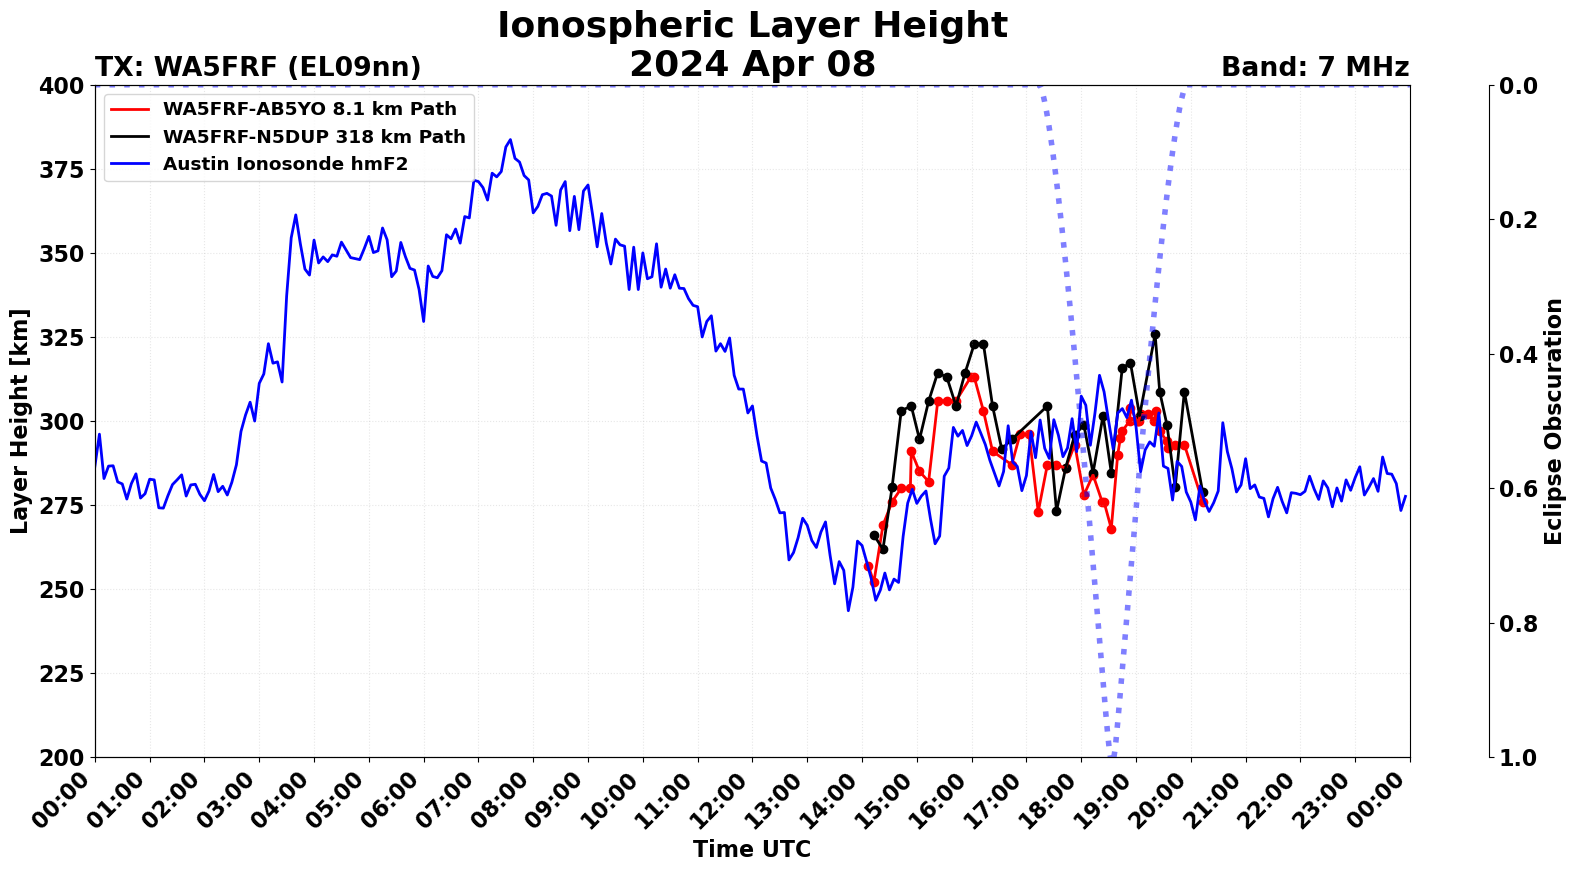

In [2]:
# Create PathInfo objects to get path information
path_info_ab5yo = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m')
path_info_n5dup = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m')

# Get solar coordinates for eclipse overlay
solar_lat, solar_lon = path_info_ab5yo.get_midpoint()

# Date for titles
date = datetime.datetime(2024, 4, 8)

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

# Set time limits for x-axis - full day
xlim = (datetime.datetime(2024, 4, 8), datetime.datetime(2024, 4, 9))
ylim = (200, 400)

# Plot WA5FRF-AB5YO path (8.8 km)
ab5yo_range = path_info_ab5yo.get_range_km()
tdoa.overlay_tdoa_csv(
    ax,
    csv_path='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_analysis.csv',
    model_coeffs=(1, 0),  # No transformation needed - data already in km
    overlay_manual=True,
    overlay_autocorr=False,
    manual_label=f'WA5FRF-AB5YO {ab5yo_range:.1f} km Path',
    manual_color='red',
    manual_linestyle='solid'
)

# Plot WA5FRF-N5DUP path (317 km)
n5dup_range = path_info_n5dup.get_range_km()
tdoa.overlay_tdoa_csv(
    ax,
    csv_path='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_analysis.csv',
    model_coeffs=(1, 0),  # No transformation needed - data already in km
    overlay_manual=True,
    overlay_autocorr=False,
    manual_label=f'WA5FRF-N5DUP {n5dup_range:.0f} km Path',
    manual_color='black',
    manual_linestyle='solid'
)

# Plot Austin ionosonde hmF2
tdoa.overlay_ionosonde(
    ax,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='blue'
)

# Add eclipse overlay
from hf_tdoa import solarContext
solar_ts = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
solar_ts.overlayEclipse(ax)

# Format x-axis with datetime formatting
from matplotlib import dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))  # Hourly ticks for full day

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_ylabel('Layer Height [km]')
ax.set_xlabel('Time UTC')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize='small')

# Add custom title for multiple paths
# Center title with date and frequency info
ax.set_title('Ionospheric Layer Height\n2024 Apr 08', loc='center', fontsize=26)
# Left title with transmitter info
ax.set_title('TX: WA5FRF (EL09nn)', loc='left')
# Right title with frequency
ax.set_title('Band: 7 MHz', loc='right')

# Rotate x-axis labels
for tick_label in ax.get_xticklabels():
    tick_label.set_rotation(45)
    tick_label.set_horizontalalignment('right')

plt.tight_layout()

# Save figure
plt.savefig('fig_09.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Figure saved to: fig_09.jpg")

plt.show()